### Imports

In [12]:
import requests
import pandas as pd
from pathlib import Path
import time

### setup paths

In [13]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = REPO_ROOT / "data" / "raw" / "511"
DATA_RAW.mkdir(parents=True, exist_ok=True)

### config

In [14]:
BASE_URL = "https://511on.ca/api/v2/get"

ENDPOINTS = {
    "events": f"{BASE_URL}/event",
    "construction": f"{BASE_URL}/constructionprojects",
}

PARAMS = {
    "format": "json",
    "lang": "en"
}

### helper to fetch JSON safely

In [15]:
def fetch_511_json(url: str, params: dict, pause_sec: float = 1.0):
    resp = requests.get(url, params=params, timeout=60)
    print("URL:", resp.url)
    print("Status:", resp.status_code)
    print("Content-Type:", resp.headers.get("Content-Type"))
    resp.raise_for_status()
    time.sleep(pause_sec)  # respect throttling
    return resp.json()

### fetch both endpoints

In [16]:
events_json = fetch_511_json(ENDPOINTS["events"], PARAMS)
construction_json = fetch_511_json(ENDPOINTS["construction"], PARAMS)

print(type(events_json), type(construction_json))
print("events records:", len(events_json))
print("construction records:", len(construction_json))

URL: https://511on.ca/api/v2/get/event?format=json&lang=en
Status: 200
Content-Type: application/json; charset=utf-8
URL: https://511on.ca/api/v2/get/constructionprojects?format=json&lang=en
Status: 200
Content-Type: application/json; charset=utf-8
<class 'list'> <class 'list'>
events records: 292
construction records: 57


### convert to DataFrames

In [17]:
events_df = pd.DataFrame(events_json)
construction_df = pd.DataFrame(construction_json)

print("events_df shape:", events_df.shape)
print("construction_df shape:", construction_df.shape)

events_df shape: (292, 25)
construction_df shape: (57, 22)


### inspect columns

In [18]:
print("EVENTS COLUMNS:")
print(events_df.columns.tolist())

print("\nCONSTRUCTION COLUMNS:")
print(construction_df.columns.tolist())

EVENTS COLUMNS:
['ID', 'SourceId', 'Organization', 'RoadwayName', 'DirectionOfTravel', 'Description', 'Reported', 'LastUpdated', 'StartDate', 'PlannedEndDate', 'LanesAffected', 'Latitude', 'Longitude', 'LatitudeSecondary', 'LongitudeSecondary', 'EventType', 'EventSubType', 'IsFullClosure', 'Severity', 'Comment', 'EncodedPolyline', 'Restrictions', 'Recurrence', 'RecurrenceSchedules', 'LinkId']

CONSTRUCTION COLUMNS:
['ID', 'SourceId', 'Organization', 'RoadwayName', 'DirectionOfTravel', 'Description', 'Reported', 'LastUpdated', 'StartDate', 'PlannedEndDate', 'LanesAffected', 'Latitude', 'Longitude', 'LatitudeSecondary', 'LongitudeSecondary', 'EventType', 'IsFullClosure', 'Comment', 'EncodedPolyline', 'Recurrence', 'RecurrenceSchedules', 'LinkId']


### inspect first rows

In [19]:
print("EVENTS HEAD:")
display(events_df.head())

print("CONSTRUCTION HEAD:")
display(construction_df.head())

EVENTS HEAD:


,ID,SourceId,Organization,RoadwayName,DirectionOfTravel,Description,Reported,LastUpdated,StartDate,PlannedEndDate,...,EventType,EventSubType,IsFullClosure,Severity,Comment,EncodedPolyline,Restrictions,Recurrence,RecurrenceSchedules,LinkId
0,86216,51887,MTO,HWY 17,Eastbound,Recurring-Construction on HWY 17 Eastbound be...,1757502000,1757532060,1757502000,1.785539e+09,...,roadwork,None,False,Unknown,,wlghH|e`kODZLlATtBLjANnAJz@BXRdBXhCHt@PxARdBJz...,"{'Width': None, 'Height': None, 'Length': None...",,,908397009
1,86217,51888,MTO,HWY 614,Northbound,Recurring-Construction on HWY 614 Northbound ...,1757502000,1757532180,1757502000,1.785539e+09,...,roadwork,None,False,Unknown,,}lghHtf`kOmAQeBKgAIk@Co@Cw@EaDOsDSmBIkG[}@GkCM...,"{'Width': None, 'Height': None, 'Length': None...",,,907756394
2,86218,51889,MTO,HWY 627,Northbound,Recurring-Construction on HWY 627 Northbound ...,1757502000,1757532240,1757502000,1.785539e+09,...,roadwork,None,False,Unknown,,NaN,"{'Width': None, 'Height': None, 'Length': None...",,,778231365
3,101532,52473,MTO,HWY 17,Eastbound,Recurring-Construction on HWY 17 Eastbound be...,1759851000,1759851060,1759851000,1.785038e+09,...,roadwork,None,False,Unknown,,qsihHjbjiO?hABfDFvBLvBThCd@pDh@xCb@pBh@vB~@nDz...,"{'Width': None, 'Height': None, 'Length': None...",,,1142045098
4,102271,52513,MTO,HWY 11,Northbound,Recurring-Construction on HWY 11 Northbound b...,1760007600,1760033460,1760007600,1.785020e+09,...,roadwork,None,False,Unknown,,NaN,"{'Width': None, 'Height': None, 'Length': None...",,,119085885


CONSTRUCTION HEAD:


,ID,SourceId,Organization,RoadwayName,DirectionOfTravel,Description,Reported,LastUpdated,StartDate,PlannedEndDate,...,Longitude,LatitudeSecondary,LongitudeSecondary,EventType,IsFullClosure,Comment,EncodedPolyline,Recurrence,RecurrenceSchedules,LinkId
0,394,2022-2022-43156276,MTO-constructions,427,Southbound,Expect delays up to 10 minutes.\n \n Expect 10...,1680840000,1772760082,1680840000,1766466000,...,-79.592157,None,None,roadwork,False,"March 06, 2026 - March 13, 2026",uqqiG~ixdN,,,29573020
1,395,2022-2017-809023677,MTO-constructions,400,N/A,There is no impact on traffic.\n Highway 400 ...,1652241600,1772760105,1652241600,1782792000,...,-79.566010,None,None,roadwork,False,"March 06, 2026 - March 13, 2026",ofakGpfsdNoUjDkAPiIlA_LbB{u@~KoG~@}KbBkBVqWzD_...,,,29602591
2,396,2022-2013-1039858069,MTO-constructions,401,Eastbound,Expect delays up to 10 minutes.\n Highway 401 ...,1649044800,1772741453,1649044800,1764133200,...,-79.338001,None,None,roadwork,False,"March 06, 2026 - March 13, 2026",{jcjGnufcNFxBB^@^TpIb@xQ^hQ@h@XpKTdKVnOt@bb@Zz...,,,707572303
3,397,2021-2127-1267923760,MTO-constructions,QEW,N/A,Expect delays up to 10 minutes.\n Queen Elizab...,1648008000,1772760183,1648008000,1785038400,...,-79.570268,None,None,roadwork,False,"March 06, 2026 - March 13, 2026",kuaiGdatdN,,,778290517
4,398,2021-2002-991301780,MTO-constructions,401,C,Expect delays up to 10 minutes.\n Highway 401/...,1655265600,1772760214,1655265600,1761278400,...,-79.660233,None,None,roadwork,False,"March 06, 2026 - March 13, 2026",{hjiGlseeN,,,1297714514


### inspect likely date fields

In [20]:
date_fields = ["Reported", "LastUpdated", "StartDate", "PlannedEndDate"]

for df_name, df in [("events", events_df), ("construction", construction_df)]:
    print(f"\n--- {df_name.upper()} DATE FIELD CHECK ---")
    for c in date_fields:
        if c in df.columns:
            print(c, "exists")
            print(df[c].head())


--- EVENTS DATE FIELD CHECK ---
Reported exists
0    1757502000
1    1757502000
2    1757502000
3    1759851000
4    1760007600
Name: Reported, dtype: int64
LastUpdated exists
0    1757532060
1    1757532180
2    1757532240
3    1759851060
4    1760033460
Name: LastUpdated, dtype: int64
StartDate exists
0    1757502000
1    1757502000
2    1757502000
3    1759851000
4    1760007600
Name: StartDate, dtype: int64
PlannedEndDate exists
0    1.785539e+09
1    1.785539e+09
2    1.785539e+09
3    1.785038e+09
4    1.785020e+09
Name: PlannedEndDate, dtype: float64

--- CONSTRUCTION DATE FIELD CHECK ---
Reported exists
0    1680840000
1    1652241600
2    1649044800
3    1648008000
4    1655265600
Name: Reported, dtype: int64
LastUpdated exists
0    1772760082
1    1772760105
2    1772741453
3    1772760183
4    1772760214
Name: LastUpdated, dtype: int64
StartDate exists
0    1680840000
1    1652241600
2    1649044800
3    1648008000
4    1655265600
Name: StartDate, dtype: int64
PlannedEndDat

### convert timestamps to readable datetimes

In [21]:
def add_datetime_columns(df: pd.DataFrame):
    for c in ["Reported", "LastUpdated", "StartDate", "PlannedEndDate"]:
        if c in df.columns:
            df[c + "_dt"] = pd.to_datetime(df[c], unit="s", utc=True, errors="coerce")
    return df

events_df = add_datetime_columns(events_df)
construction_df = add_datetime_columns(construction_df)

events_df[[c for c in events_df.columns if c.endswith("_dt")]].head()

,Reported_dt,LastUpdated_dt,StartDate_dt,PlannedEndDate_dt
0,2025-09-10 11:00:00+00:00,2025-09-10 19:21:00+00:00,2025-09-10 11:00:00+00:00,2026-07-31 23:00:00+00:00
1,2025-09-10 11:00:00+00:00,2025-09-10 19:23:00+00:00,2025-09-10 11:00:00+00:00,2026-07-31 23:00:00+00:00
2,2025-09-10 11:00:00+00:00,2025-09-10 19:24:00+00:00,2025-09-10 11:00:00+00:00,2026-07-31 23:00:00+00:00
3,2025-10-07 15:30:00+00:00,2025-10-07 15:31:00+00:00,2025-10-07 15:30:00+00:00,2026-07-26 03:59:00+00:00
4,2025-10-09 11:00:00+00:00,2025-10-09 18:11:00+00:00,2025-10-09 11:00:00+00:00,2026-07-25 23:00:00+00:00


### geometry / location check

In [22]:
location_cols = [
    "Latitude", "Longitude",
    "LatitudeSecondary", "LongitudeSecondary",
    "EncodedPolyline"
]

for df_name, df in [("events", events_df), ("construction", construction_df)]:
    print(f"\n--- {df_name.upper()} LOCATION CHECK ---")
    existing = [c for c in location_cols if c in df.columns]
    print("Existing location columns:", existing)
    if "Latitude" in df.columns and "Longitude" in df.columns:
        print(df[["Latitude", "Longitude"]].head())
    if "EncodedPolyline" in df.columns:
        print("EncodedPolyline non-null count:", df["EncodedPolyline"].notna().sum())


--- EVENTS LOCATION CHECK ---
Existing location columns: ['Latitude', 'Longitude', 'LatitudeSecondary', 'LongitudeSecondary', 'EncodedPolyline']
    Latitude  Longitude
0  48.792290  -87.20525
1  48.703644  -85.85839
2  48.664608  -86.28227
3  48.714930  -85.58052
4  49.614900  -87.95427
EncodedPolyline non-null count: 153

--- CONSTRUCTION LOCATION CHECK ---
Existing location columns: ['Latitude', 'Longitude', 'LatitudeSecondary', 'LongitudeSecondary', 'EncodedPolyline']
    Latitude  Longitude
0  43.676587 -79.592157
1  43.920557 -79.566010
2  43.767657 -79.338001
3  43.595259 -79.570268
4  43.639338 -79.660233
EncodedPolyline non-null count: 57


### save raw snapshots locally

In [23]:

events_df.to_parquet(DATA_RAW / "events_snapshot.parquet", index=False)
construction_df.to_parquet(DATA_RAW / "construction_snapshot.parquet", index=False)

print("Saved raw 511 snapshots to:", DATA_RAW)

Saved raw 511 snapshots to: C:\code\pyspark-playground\Covercheck-Toronto\data\raw\511


### Categorical & Severity Breakdown

C:\Users\sriva\AppData\Local\Temp\ipykernel_39496\2001206533.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=events_df, x='Severity', ax=ax[0], palette='viridis')


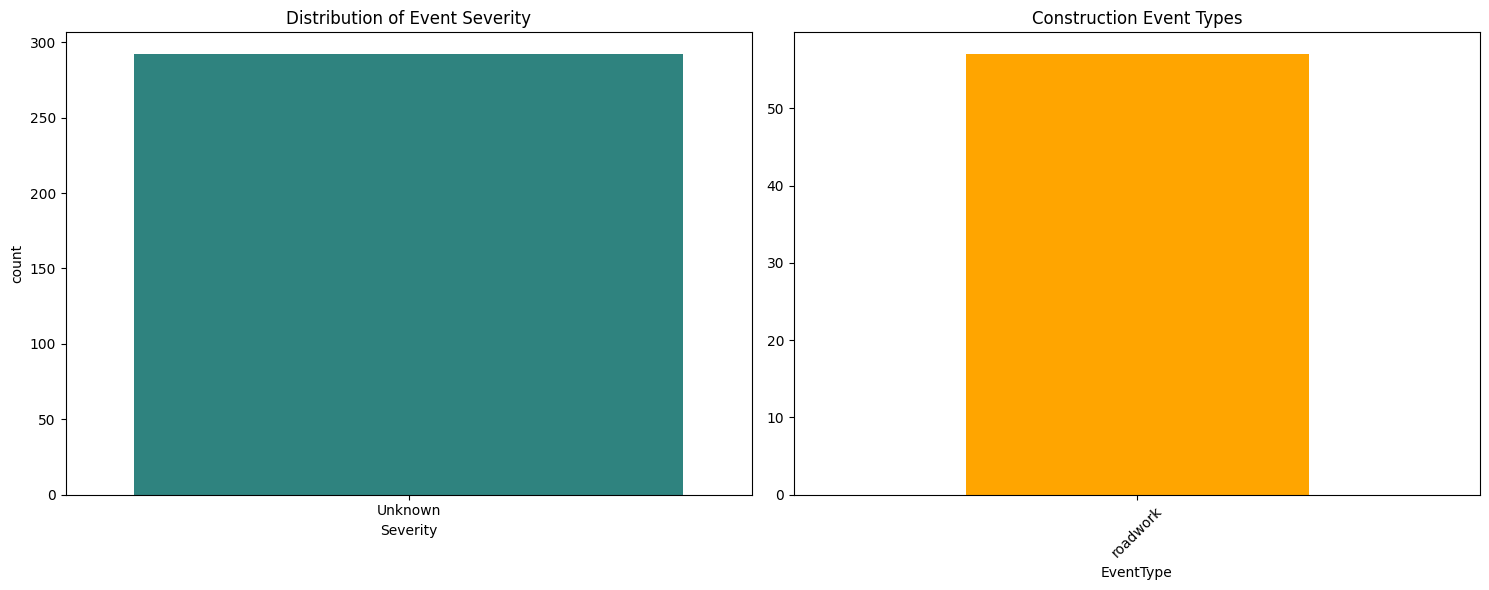

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

#events severity
sns.countplot(data=events_df, x='Severity', ax=ax[0], palette='viridis')
ax[0].set_title('Distribution of Event Severity')

#construction event types
if 'EventType' in construction_df.columns:
    construction_df['EventType'].value_counts().plot(kind='bar', ax=ax[1], color='orange')
    ax[1].set_title('Construction Event Types')
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Temporal analysis

Average Event Duration: 9.70 days
Average Construction Duration: 811.40 days


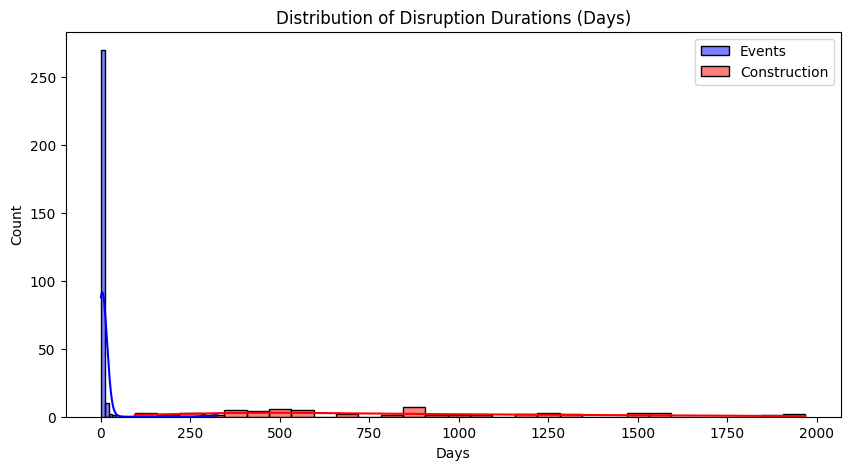

In [26]:
events_df['duration_days'] = (events_df['PlannedEndDate_dt'] - events_df['StartDate_dt']).dt.total_seconds() / 86400
construction_df['duration_days'] = (construction_df['PlannedEndDate_dt'] - construction_df['StartDate_dt']).dt.total_seconds() / 86400

print(f"Average Event Duration: {events_df['duration_days'].mean():.2f} days")
print(f"Average Construction Duration: {construction_df['duration_days'].mean():.2f} days")

plt.figure(figsize=(10, 5))
sns.histplot(events_df['duration_days'].dropna(), bins=30, kde=True, label='Events', color='blue')
sns.histplot(construction_df['duration_days'].dropna(), bins=30, kde=True, label='Construction', color='red')
plt.title('Distribution of Disruption Durations (Days)')
plt.xlabel('Days')
plt.legend()
plt.show()

### Geospatial Validation (Folium Map)

In [28]:
import folium
from folium.plugins import MarkerCluster

#center map on toronto
m = folium.Map(location=[43.7, -79.4], zoom_start=10)
marker_cluster = MarkerCluster().add_to(m)

#adding events to map
for idx, row in events_df.dropna(subset=['Latitude', 'Longitude']).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Event: {row['EventType']} - {row['Severity']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)

#adding construction to map
for idx, row in construction_df.dropna(subset=['Latitude', 'Longitude']).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Construction: {row['RoadwayName']}",
        icon=folium.Icon(color='orange', icon='wrench', prefix='fa')
    ).add_to(marker_cluster)

m.save(str(REPO_ROOT / "data" / "raw" / "511" / "disruption_map.html"))
print("Map saved to data/raw/511/disruption_map.html")
m

Map saved to data/raw/511/disruption_map.html
